# FitCream Agent Graph 测试

测试完整的 React Agent 流程：
- Agent 构建与初始化
- 基础对话（无 Tool 调用）
- Tool 调用（计划生成、打卡、统计查询）
- 流式输出（SSE 事件模拟）
- 中间件集成（日志、限流、Token 追踪）
- 多轮对话（checkpointer）

参考: https://docs.langchain.com/oss/python/langchain/agents

## 0. 环境准备

In [1]:
import os
import sys
import asyncio
from dotenv import load_dotenv

# 加载环境变量
load_dotenv()

# 将 rogers 目录加入 path（确保能 import agents/app）
rogers_dir = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
if rogers_dir not in sys.path:
    sys.path.insert(0, rogers_dir)

print(f"工作目录: {rogers_dir}")
print(f"DASHSCOPE_API_KEY 已配置: {bool(os.getenv('DASHSCOPE_API_KEY'))}")
print(f"DATABASE_URL 已配置: {bool(os.getenv('DATABASE_URL'))}")

## 1. 构建 Agent（无 checkpointer）

使用 `create_fitcream_agent` 工厂函数创建 Agent 实例。

In [2]:
from agents.agent.agent_factory import create_fitcream_agent
from agents.harness.prompts.system import SYSTEM_PROMPT

# 创建 Agent（无 checkpointer，用于测试）
agent = create_fitcream_agent(
    system_prompt=SYSTEM_PROMPT,
    enable_thinking=True,
)

print(f"Agent 类型: {type(agent).__name__}")
print(f"System Prompt 长度: {len(SYSTEM_PROMPT)} 字符")

e:\wangtong\apps\anaconda\envs\agentenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Agent 类型: CompiledStateGraph
System Prompt 长度: 3170 字符


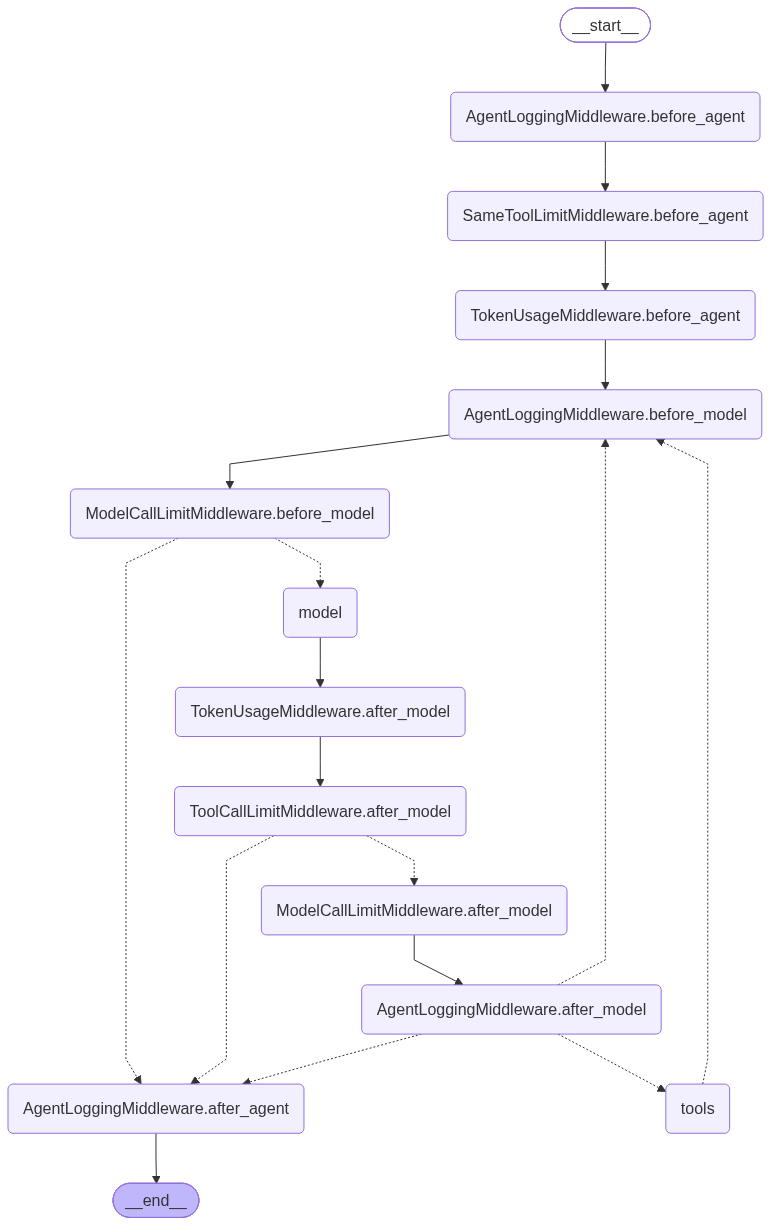

In [3]:
agent

## 2. 基础对话（invoke）

测试简单的问答，不触发 Tool 调用。

In [ ]:
# 简单问答（不触发 Tool）
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "你好，你是谁？"}]},
    config={"configurable": {"thread_id": "test-001", "user_id": "test-user"}},
)

# 提取最终回复
messages = result["messages"]
last_message = messages[-1]
print(f"消息数量: {len(messages)}")
print(f"\n【AI 回复】")
print(last_message.content)

In [ ]:
result

## 3. 流式输出（stream）

使用 `astream_events` 模拟 SSE 流式输出，观察完整的事件流。

In [ ]:
# 流式输出：逐 token
print("=" * 60)
print("流式输出测试")
print("=" * 60)

config = {"configurable": {"thread_id": "test-002", "user_id": "test-user"}}
input_msg = {"messages": [{"role": "user", "content": "给我一些健身建议"}]}

in_thinking = False

async for event in agent.astream_events(input_msg, config=config, version="v2"):
    kind = event["event"]
    
    if kind == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        
        # 思考内容
        reasoning = chunk.additional_kwargs.get("reasoning_content", "")
        if reasoning:
            if not in_thinking:
                print("\033[90m[思考] ", end="")
                in_thinking = True
            print(f"\033[90m{reasoning}\033[0m", end="", flush=True)
        
        # 正式回复
        if chunk.content:
            if in_thinking:
                print("\033[0m\n[回复] ", end="")
                in_thinking = False
            print(chunk.content, end="", flush=True)

if in_thinking:
    print("\033[0m")
print("\n\n[流式输出结束]")

## 4. Tool 调用测试 - 查询动作库

触发 `get_exercises_tool`，验证 Agent 能正确选择并调用 Tool。

In [ ]:
# Tool 调用：查询动作
print("=" * 60)
print("Tool 调用测试 - 查询动作库")
print("=" * 60)

config = {"configurable": {"thread_id": "test-003", "user_id": "test-user"}}
input_msg = {"messages": [{"role": "user", "content": "推荐几个练胸的动作"}]}

async for event in agent.astream_events(input_msg, config=config, version="v2"):
    kind = event["event"]
    
    if kind == "on_tool_start":
        print(f"\n🔧 [Tool 开始] {event['name']}")
        print(f"   输入: {event['data'].get('input', '')}")
    
    elif kind == "on_tool_end":
        print(f"\n✅ [Tool 完成] {event['name']}")
        output = event["data"].get("output", "")
        # 截断过长的输出
        output_str = str(output)
        print(f"   输出: {output_str[:300]}{'...' if len(output_str) > 300 else ''}")
    
    elif kind == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        if chunk.content:
            print(chunk.content, end="", flush=True)

print("\n")

## 5. Tool 调用测试 - 生成训练计划

触发 `create_plan_tool`，验证完整的计划生成流程。

In [ ]:
# Tool 调用：生成计划
print("=" * 60)
print("Tool 调用测试 - 生成训练计划")
print("=" * 60)

config = {"configurable": {"thread_id": "test-004", "user_id": "test-user"}}
input_msg = {"messages": [{"role": "user", "content": "我想减脂，每周能练4天，帮我制定一个计划"}]}

tool_calls = []

async for event in agent.astream_events(input_msg, config=config, version="v2"):
    kind = event["event"]
    
    if kind == "on_tool_start":
        tool_name = event["name"]
        tool_calls.append(tool_name)
        print(f"\n🔧 [Tool] {tool_name}")
    
    elif kind == "on_tool_end":
        output = event["data"].get("output", "")
        output_str = str(output)
        print(f"✅ [完成] {output_str[:200]}{'...' if len(output_str) > 200 else ''}")
    
    elif kind == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        if chunk.content:
            print(chunk.content, end="", flush=True)

print(f"\n\n📊 调用的 Tools: {tool_calls}")

## 6. 中间件集成测试

使用 `create_agent_with_middleware` 创建含编译时中间件的 Agent。
中间件（日志、限流、Token 追踪）在 `create_agent` 时注入，无需运行时 callbacks。

In [ ]:
from agents.agent_graph import create_agent_with_middleware
import logging

# 配置日志输出
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

# 创建含中间件的 Agent（中间件编译时注入）
mw_agent = create_agent_with_middleware(
    user_id="test-user-middleware",
    thread_id="test-mw-001",
    verbose=True,
    max_tool_calls=5,
    max_llm_calls=10,
    save_conversation=False,
)

print(f"Agent 类型: {type(mw_agent).__name__}")
print(f"Nodes: {list(mw_agent.nodes.keys())}")

In [ ]:
# 使用含中间件的 Agent 运行
print("=" * 60)
print("中间件集成测试")
print("=" * 60)

config = {"configurable": {"thread_id": "test-mw-001", "user_id": "test-user-middleware"}}
input_msg = {"messages": [{"role": "user", "content": "这周练得怎么样？"}]}

async for event in mw_agent.astream_events(input_msg, config=config, version="v2"):
    kind = event["event"]
    
    if kind == "on_tool_start":
        print(f"\n🔧 [Tool] {event['name']}")
    elif kind == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        if chunk.content:
            print(chunk.content, end="", flush=True)

print("\n[完成]")

## 7. 多轮对话测试

模拟多轮对话，验证上下文保持（需要 checkpointer 或手动传递 messages）。

In [ ]:
# 多轮对话（手动维护 messages 列表）
print("=" * 60)
print("多轮对话测试")
print("=" * 60)

config = {"configurable": {"thread_id": "test-multi", "user_id": "test-user"}}
messages = []

# 第一轮
messages.append({"role": "user", "content": "我叫小明，我想增肌"})
result = await agent.ainvoke({"messages": messages}, config=config)
messages = result["messages"]  # 更新 messages（含 AI 回复）
print(f"[轮1] AI: {messages[-1].content[:200]}...\n")

# 第二轮（引用上下文）
messages.append({"role": "user", "content": "我叫什么名字？我的目标是什么？"})
result = await agent.ainvoke({"messages": messages}, config=config)
messages = result["messages"]
print(f"[轮2] AI: {messages[-1].content[:200]}...")

## 8. 完整 SSE 事件流模拟

模拟 FastAPI SSE 端点的完整事件流格式。

In [ ]:
import json

def format_sse(event: str, data: dict) -> str:
    """格式化 SSE 消息"""
    return f"event: {event}\ndata: {json.dumps(data, ensure_ascii=False)}\n\n"

print("=" * 60)
print("SSE 事件流模拟")
print("=" * 60)

config = {"configurable": {"thread_id": "test-sse", "user_id": "test-user"}}
input_msg = {"messages": [{"role": "user", "content": "帮我查一下练腿的动作"}]}

sse_events = []

async for event in agent.astream_events(input_msg, config=config, version="v2"):
    kind = event["event"]
    
    if kind == "on_chat_model_stream":
        content = event["data"]["chunk"].content
        if content:
            sse_events.append(format_sse("token", {"content": content}))
    
    elif kind == "on_tool_start":
        sse_events.append(format_sse("tool_start", {"tool": event["name"]}))
    
    elif kind == "on_tool_end":
        output = event["data"].get("output", {})
        sse_events.append(format_sse("tool_result", {
            "tool": event["name"],
            "data": str(output)[:200],
        }))

# 结束事件
sse_events.append(format_sse("done", {"thread_id": "test-sse"}))

# 打印前 10 个 SSE 事件
print(f"总事件数: {len(sse_events)}\n")
print("前 10 个事件:")
print("-" * 40)
for i, sse in enumerate(sse_events[:10]):
    print(f"[{i+1}] {sse.strip()}")
    print()

## 9. 错误处理测试

测试 Tool 执行失败时 Agent 的容错能力。

In [ ]:
# 测试边界情况：模糊请求
print("=" * 60)
print("边界情况测试")
print("=" * 60)

config = {"configurable": {"thread_id": "test-edge", "user_id": "test-user"}}

# 模糊请求（Agent 应该追问而不是盲目调用 Tool）
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "帮我弄个计划"}]},
    config=config,
)

print(f"AI 回复: {result['messages'][-1].content}")
print(f"消息数: {len(result['messages'])}")

## 10. 性能基准

测量 Agent 响应时间。

In [ ]:
import time

print("=" * 60)
print("性能基准测试")
print("=" * 60)

config = {"configurable": {"thread_id": "test-perf", "user_id": "test-user"}}

# 简单问答
start = time.time()
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "你好"}]},
    config=config,
)
simple_time = time.time() - start

# Tool 调用
start = time.time()
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "推荐练背的动作"}]},
    config=config,
)
tool_time = time.time() - start

print(f"简单问答: {simple_time:.2f}s")
print(f"Tool 调用: {tool_time:.2f}s")
print(f"消息数: {len(result['messages'])}")